<a href="https://colab.research.google.com/github/Shahad-Hossain/nasa-image-enhancement/blob/main/Homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cv2 as cv
from numpy.lib.stride_tricks import sliding_window_view

# typing
from collections import defaultdict
from typing import List, Tuple

# drive
from google.colab import drive

In [ ]:
def patch(image: np.ndarray, height : int , width: int, ksize: int) -> np.ndarray:
  return image[height: height + ksize, width: width + ksize]

In [ ]:
def showHighlight(image: np.ndarray, height: int, width: int, ksize: int, title: str) -> None:
    fig, ax = plt.subplots(figsize=(6,6))
    ax.imshow(image, cmap="gray")

    rect = Rectangle(
        (width, height),
        ksize,
        ksize,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )

    ax.add_patch(rect)

    plt.title(f"{ksize}x{ksize} Area Patch from {title}")
    plt.axis("off")
    plt.show()

In [ ]:
def show(image: np.ndarray, cmap=None, title=None):
  try:
    plt.imshow(image, cmap=cmap, vmin=0, vmax=255)
    plt.title(title)
    plt.axis("off")
  except Exception as e:
    return ValueError(f"Unknown error occured: {e}")

In [ ]:
def toGrayFloat(image: np.ndarray) -> np.ndarray:
    if image.ndim == 3:
        return np.mean(image.astype(np.float32), axis=2)
    else:
        return image.astype(np.float32)

In [ ]:
def showHistogram(image: np.ndarray, title: str = "", bins: int = 256) -> None:
    """
    Displays histogram of an image (grayscale or RGB).
    Automatically handles float and uint8 images.
    """

    # Convert to grayscale float
    imageGray = toGrayFloat(image)

    flat = imageGray.flatten()

    maxVal = flat.max()
    minVal = flat.min()

    plt.figure()
    plt.hist(flat, bins=bins, density=True)
    plt.title(title)
    plt.xlabel("Intensity Value")
    plt.ylabel("Frequency")
    plt.show()

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def saveImageToDrive(filename: str, driveFolder: str = '/CSC475/Homework4') -> None:
  try:
    image = cv.imread(filename)

    if image is None:
        print("Image not found.")
        return

    imagePath = f"/content/drive/MyDrive/{driveFolder}/{filename}"

    cv.imwrite(imagePath, image)
    print(f'Image successfully saved to: {imagePath}')

  except Exception as e:
    print(f'Error saving image to Drive: {e}')


def loadImageFromDrive(filename: str, driveFolder: str = '/CSC475/Homework4') -> np.ndarray:
  """
  Loads an image from Google Drive into a NumPy array.
  """
  try:
    filePath = f"/content/drive/MyDrive/{driveFolder}/{filename}"

    loadedImgBgr = cv.imread(filePath)

    print(f'Image successfully loaded from: {filePath}')
    return cv.cvtColor(loadedImgBgr, cv.COLOR_BGR2GRAY)

  except Exception as e:
    print(f'Error loading image from Drive: {e}')
    return None

In [ ]:
#imgFilePath = f"Mars_Perseverance_ZL0_1781_0825051171_178EBY_N0860356ZCAM07125_1100LMJ.png"
#imgFilePath = f"Mars_Perseverance_NRF_1785_0825406007_909ECM_N0860510NCAM00347_07_195J.png"
imgFilePath = f"eaxmple.jpg"

# Save image
saveImageToDrive(filename=imgFilePath)

Image not found.


Image successfully loaded from: /content/drive/MyDrive//CSC475/Homework4/Mars_Perseverance_NRF_1785_0825406007_909ECM_N0860510NCAM00347_07_195J.png


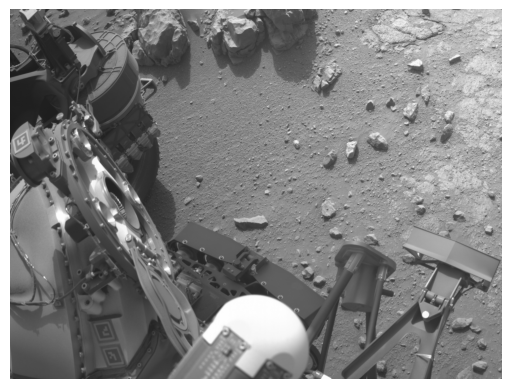

In [ ]:
# Load image
imgName = f"Mars_Perseverance_NRF_1785_0825406007_909ECM_N0860510NCAM00347_07_195J.png"

marsImage = loadImageFromDrive(imgName)

show(marsImage, cmap="gray")

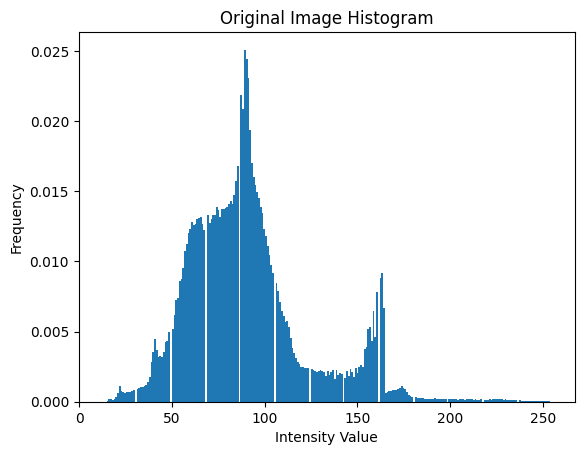

In [ ]:
showHistogram(marsImage, title="Original Image Histogram")

In [ ]:
"""
1) Generate and add 5 different noise (including Gaussian and saltand-pepper (impulse)) noise to 3 images. You must be able to specify the noise
mean and variance (for example =10, 0.8) (30 points).
"""
class Noise(object):
    def __init__(self, image: np.ndarray):
        self.image = image.astype(np.float32)
        self.shape = image.shape

    def clip(self, image: np.ndarray):
        L = 255.0
        return np.clip(image, 0, L)

    # --- Gaussian ---
    def addGaussian(self, mean: float, std: float):
        noise = self.clip(np.random.normal(mean, std, self.shape))
        return self.clip(self.image + noise), noise

    # --- Uniform ---
    def addUniform(self, low: float, high: float):
        noise = self.clip(np.random.uniform(low, high, self.shape))
        return self.clip(self.image + noise), noise

    # --- Exponential ---
    def addExponential(self, scale: float):
        noise = self.clip(np.random.exponential(scale, self.shape))
        return self.clip(self.image + noise), noise

    def applySapNoise(self, amount: float, saltVsPepper: float) -> np.ndarray:
        L = 255.0

        amount = float(np.clip(amount, 0.0, 1.0))
        saltVsPepper = float(np.clip(saltVsPepper, 0.0, 1.0))

        outputImage = self.image.copy()

        noise = np.zeros_like(self.image)

        height, width = self.image.shape[:2]
        randomMatrix = np.random.rand(height, width)

        saltProb = amount * saltVsPepper
        pepperProb = amount * (1.0 - saltVsPepper)

        pepperMask = randomMatrix < pepperProb
        saltMask = (randomMatrix >= pepperProb) & (randomMatrix < pepperProb + saltProb)

        outputImage[pepperMask] = 0
        outputImage[saltMask] = L

        noise[pepperMask] = 0
        noise[saltMask] = L

        return outputImage, noise

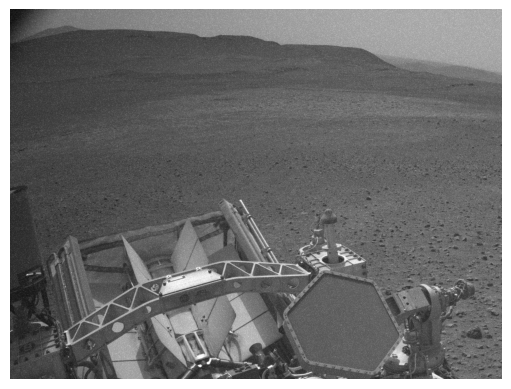

In [ ]:
mean = 0
std = 20

gaussNoisyImg, gaussNoise = Noise(marsImage).addGaussian(mean, std)

show(gaussNoisyImg, cmap="gray")

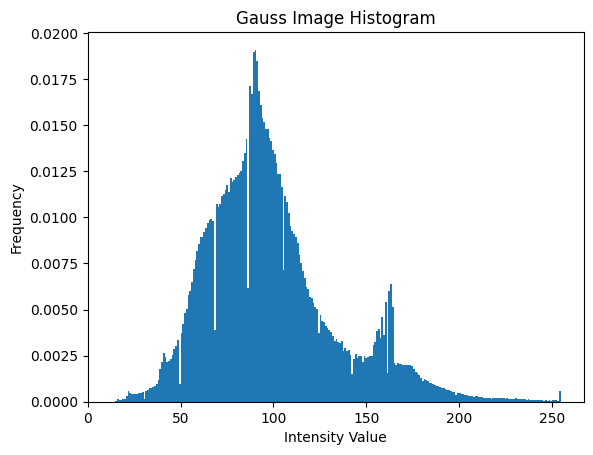

In [ ]:
showHistogram(gaussNoisyImg, title="Gauss Image Histogram")

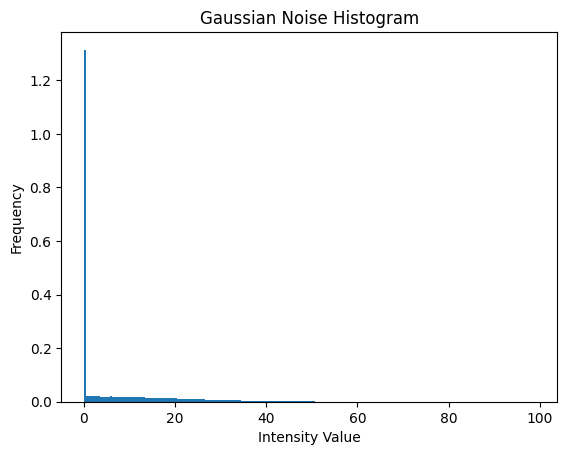

In [ ]:
showHistogram(gaussNoise, title="Gaussian Noise Histogram")

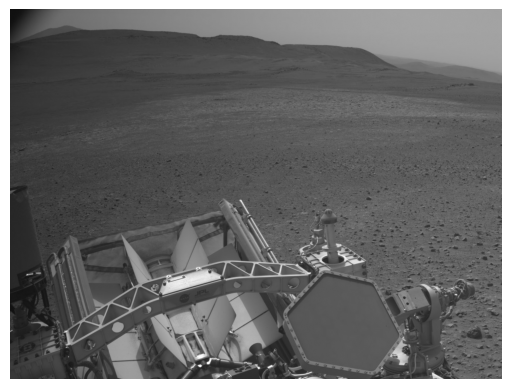

In [ ]:
show(marsImage, cmap="gray")

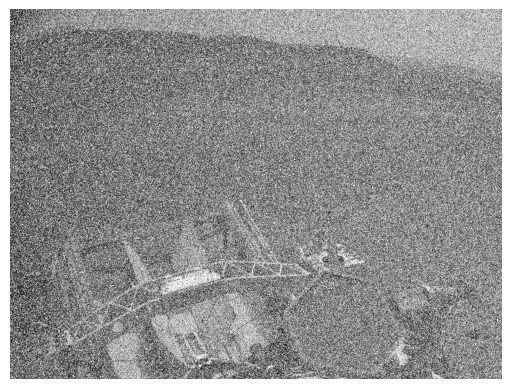

In [ ]:
amount = 0.40
saltVsPepper = 0.80

sapNoisyImg, sapNoise = Noise(marsImage).applySapNoise(amount=amount, saltVsPepper=saltVsPepper)

show(sapNoisyImg, cmap="gray")

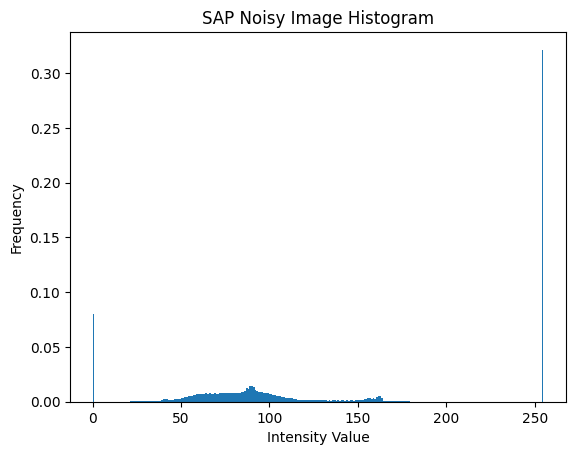

In [ ]:
showHistogram(sapNoisyImg, title="SAP Noisy Image Histogram")

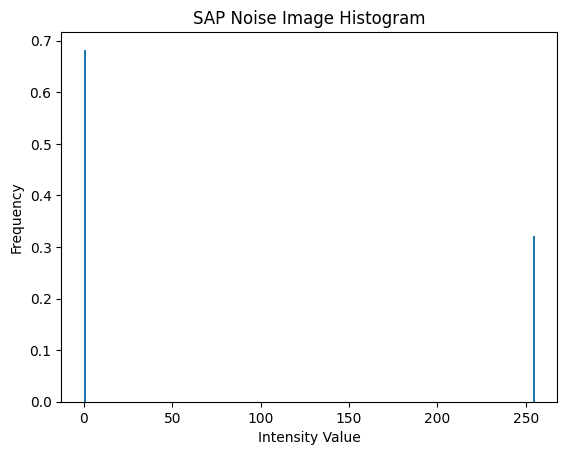

In [ ]:
showHistogram(sapNoise, title="SAP Noise Image Histogram")

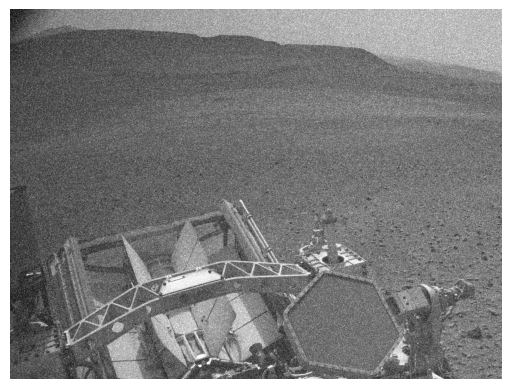

In [ ]:
low = -100
high = 100
uniformNoiseImg, uniformNoise = Noise(marsImage).addUniform(low, high)

show(uniformNoiseImg, cmap="gray")

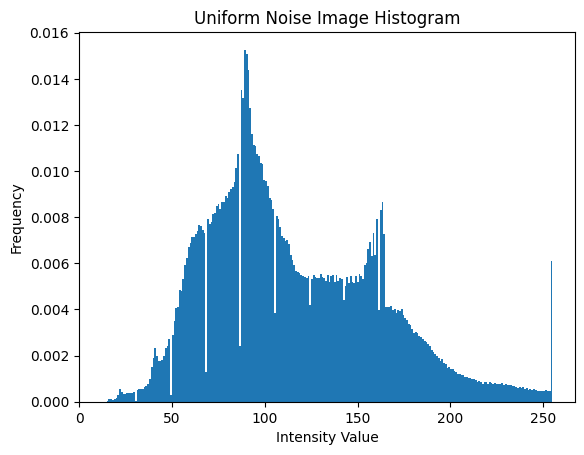

In [ ]:
showHistogram(uniformNoiseImg, title="Uniform Noise Image Histogram")

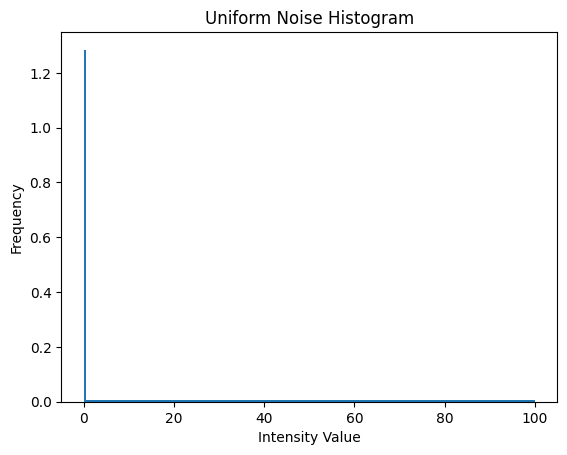

In [ ]:
showHistogram(uniformNoise, title="Uniform Noise Histogram")

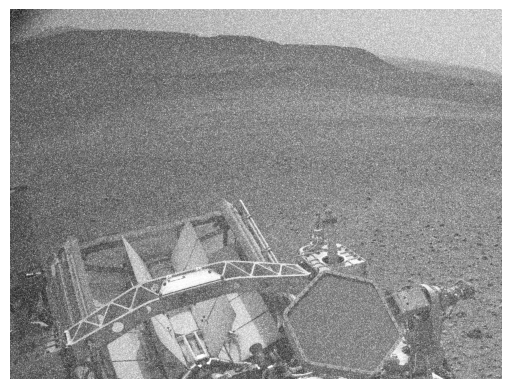

In [ ]:
a = 50
exponentialNoisyImg, exponentialNoise = Noise(marsImage).addExponential(a)

show(exponentialNoisyImg, cmap="gray")

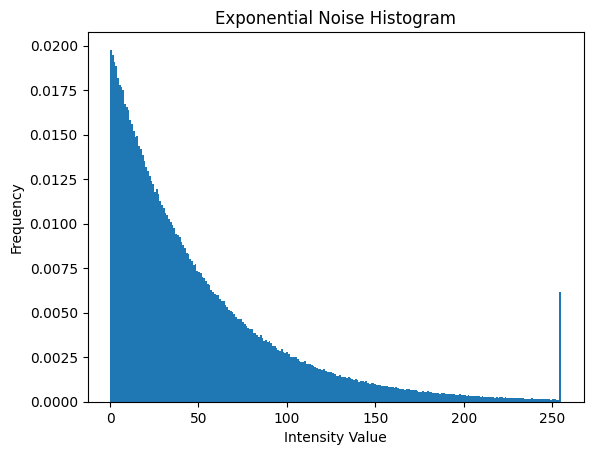

In [ ]:
showHistogram(exponentialNoise, title="Exponential Noise Histogram")

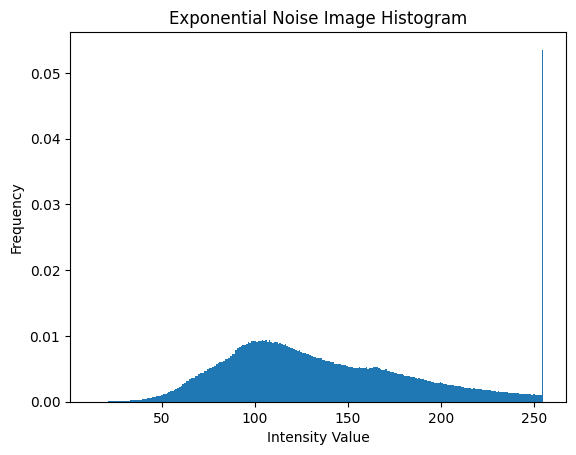

In [ ]:
showHistogram(exponentialNoisyImg, title="Exponential Noise Image Histogram")

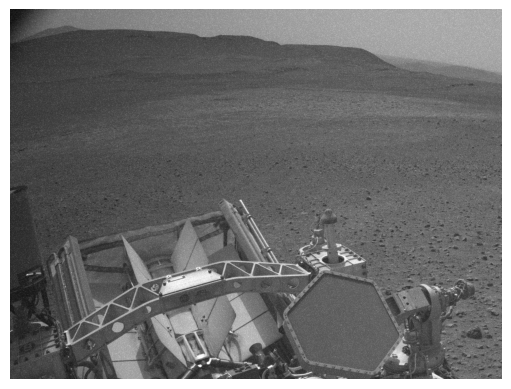

In [ ]:
show(gaussNoisyImg, cmap="gray")

In [ ]:
marsImage.shape

(968, 1288)

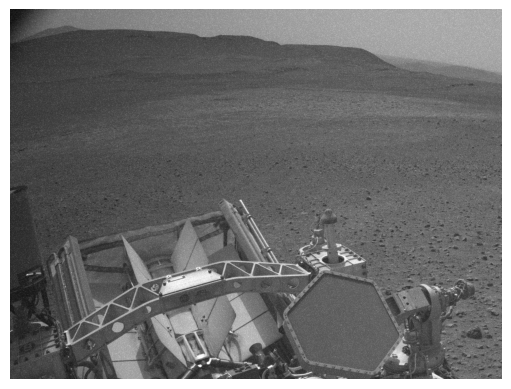

In [ ]:
show(gaussNoisyImg, cmap="gray")

In [ ]:
"""2 Estimate noise parameters from a single image (10 points)."""
height = 150
width = 1200
ksize = 25
def estimateGaussianNoise(image: np.ndarray, height: int, width: int, ksize: int):
    """
    meanValue is not recoverable without original image constant mean C
    C = 10
    """
    gaussPatch = patch(image, height, width, ksize)
    meanValue = float(np.mean(gaussPatch))
    stdDev = float(np.std(gaussPatch))
    return meanValue, stdDev

mu, sigma = estimateGaussianNoise(gaussNoisyImg, height=height, width=width, ksize=ksize)
print("Gaussian estimate:", mu, sigma)

Gaussian estimate: 127.70498759887468 18.269765832238306


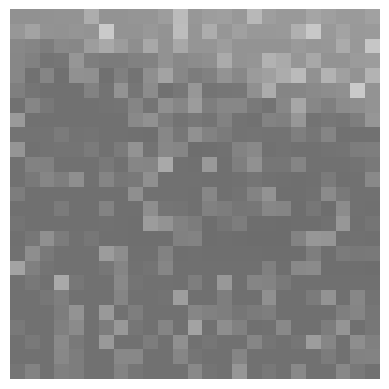

In [ ]:
gaussPatch = patch(gaussNoisyImg, height, width, ksize=25)
show(gaussPatch, cmap="gray")

In [ ]:
def estimateSapNoise(patch: np.ndarray):
    L = 255,
    lowThresh = 2.0
    highThresh = 253.0
    patch = patch.astype(np.uint8)

    pepperMask = patch <= lowThresh
    saltMask = patch >= highThresh

    numPepper = int(np.sum(pepperMask))
    numSalt = int(np.sum(saltMask))
    totalPixels = patch.size

    amount = (numPepper + numSalt) / totalPixels
    saltPepperRatio = (numSalt / (numPepper + numSalt)) if (numPepper + numSalt) > 0 else 0.5

    return float(amount), float(saltPepperRatio)

def estimateSapNoiseRgb(patch: np.ndarray):
    patchGray = toGrayFloat(patch).astype(np.uint8)
    return estimateSapNoise(patchGray)

amount, saltPepperRatio = estimateSapNoiseRgb(sapNoisyImg)
print("Estimated amount:", amount)
print("Estimated saltPepperRatio:", saltPepperRatio)

Estimated amount: 0.399922520661157
Estimated saltPepperRatio: 0.8005523277385248


In [ ]:
def meanSquaredError(noisy: np.ndarray, reference: np.ndarray) -> float:
    """
    Computes the Mean Squared Error (MSE) between two images.
    """

    if noisy.shape != reference.shape:
        raise ValueError("Images must have the same dimensions")

    # Convert to float to avoid overflow
    noisy = noisy.astype(np.float64)
    reference = reference.astype(np.float64)

    mse = np.mean((noisy - reference) ** 2)

    return float(round(mse, 2))

In [ ]:
"""
3) Apply a class of means filters: arithmetic, weighted mean,
Geometric mean, and mean filter. (25 points).
"""
class Filter(object):
  def __init__(self, image: np.ndarray):
    self.image = image

  def uint8(self, img: np.ndarray) -> np.ndarray:
    if img.dtype != np.uint8:
      img_float = img.astype(np.float32)
      if img_float.max() <= 1.0:
        img_float *= 255.0
      img = np.clip(img_float, 0, 255).astype(np.uint8)
    return img

  def medianFilter(self, ksize: int = 3):
    if ksize % 2 == 0 or ksize < 3:
      raise ValueError("ksize must be odd and >= 3")
    img = self.uint8(self.image)
    return cv.medianBlur(img, ksize)

  def arthmeticMeanFilter(self, ksize: int = 3):
    boxSize = (ksize, ksize)
    img = self.uint8(self.image)
    return cv.blur(img, boxSize)

  def weightedMeanFilter(self, ksize: int = 3):
    boxSize = (ksize, ksize)
    img = self.uint8(self.image)
    return cv.GaussianBlur(img, boxSize, 0)

  def geometricMeanFilter(self, ksize: int = 3):
    img = self.uint8(self.image).astype(np.float32)
    boxSize = (ksize, ksize)

    # geometric mean: exp(mean(log(img+eps))) - eps
    eps = 1e-6
    imageLog = np.log(img + eps)
    out = np.exp(cv.blur(imageLog, boxSize))
    return np.clip(out, 0, 255).astype(np.uint8)

  def alphaTrimFilter(self, k: int, d: int) -> np.ndarray:
    if k % 2 == 0: raise ValueError(f"k: {k} must be odd")

    if d % 2 != 0:
        raise ValueError("d must be even (so d/2 can be removed from both sides)")

    n = k * k
    if d >= n:
        raise ValueError("r too large")

    output = np.zeros_like(self.image, dtype=float)
    pad = k // 2
    padded = np.pad(self.image, pad, mode="reflect")
    neighborhoods = sliding_window_view(padded, (k, k))
    height, width = neighborhoods.shape[0:2]
    trim = d // 2

    for i in range(height):
      for j in range(width):
        neighborhood = neighborhoods[i, j]
        neighborhood = np.sort(neighborhood.flatten())
        trimNair = neighborhood[trim : n - trim]
        output[i, j] = np.mean(trimNair)

    return output

In [ ]:
size = 200  # size of each quadrant

black = np.zeros((size, size))
gray  = np.ones((size, size)) * 200   # gray intensity

marsImage = np.block([
    [black, gray],
    [gray,  black]
])

In [ ]:
height = 150
width = 1200
ksize = 25

In [ ]:
amount = 0.4
saltVsPepper = 0.8

sapNoisyImg, sapNoise = Noise(marsImage).applySapNoise(amount=amount, saltVsPepper=saltVsPepper)

In [ ]:
mean = 25
std = 25

gaussNoisyImg, gaussNoise = Noise(marsImage).addGaussian(mean, std)

In [ ]:
imgFilters = Filter(sapNoisyImg)

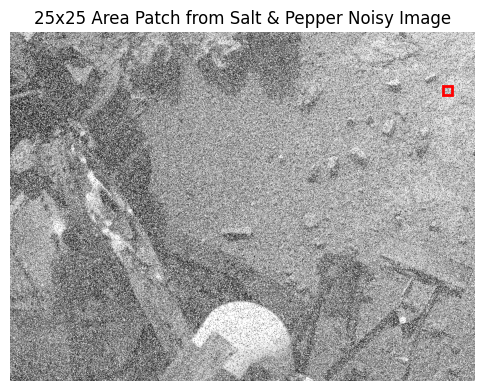

In [ ]:
showHighlight(sapNoisyImg, height = height, width = width, ksize = 25, title="Salt & Pepper Noisy Image")

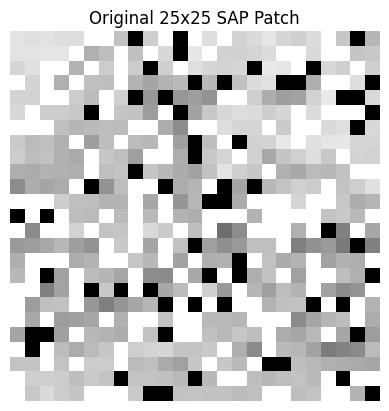

In [ ]:
show(patch(sapNoisyImg, height=height, width=width, ksize=25), cmap="gray", title="Original 25x25 SAP Patch")

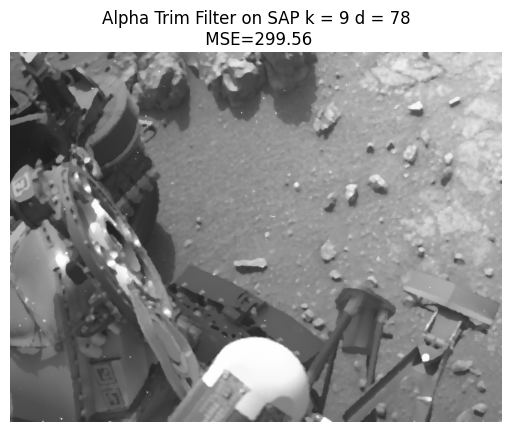

In [ ]:
k = 9
d = 78
alphaTrimFilter = imgFilters.alphaTrimFilter(k = k, d = d)
MSE = meanSquaredError(alphaTrimFilter, marsImage)
show(alphaTrimFilter, cmap="gray", title=f"Alpha Trim Filter on SAP k = {k} d = {d}\n MSE={MSE}")

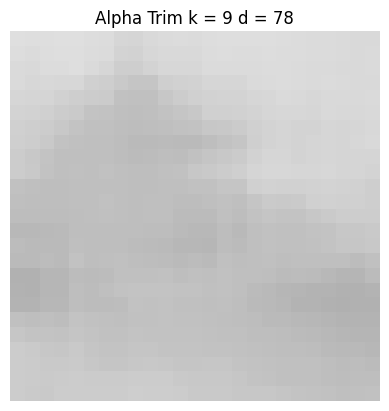

In [ ]:
show(patch(alphaTrimFilter, height=height, width=width, ksize=25), cmap="gray", title=f"Alpha Trim k = {k} d = {d}")

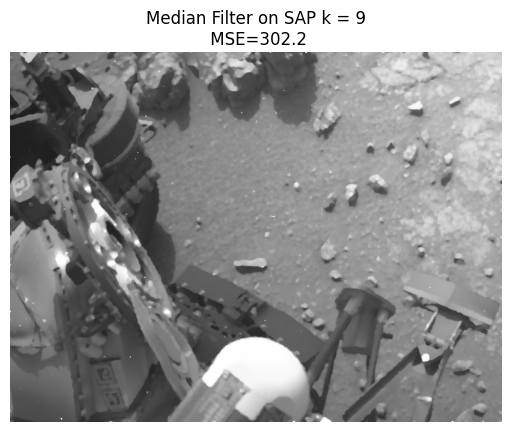

In [ ]:
medianFilter = imgFilters.medianFilter(ksize=9)
MSE = meanSquaredError(medianFilter, marsImage)
show(medianFilter, cmap="gray", title=f"Median Filter on SAP k = 9\n MSE={MSE}")

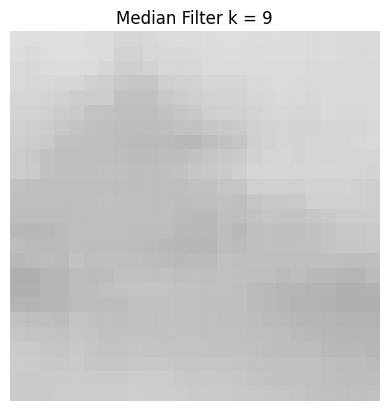

In [ ]:
show(patch(medianFilter, height=height, width=width, ksize=25), cmap="gray", title="Median Filter k = 9")

In [ ]:
"""
4) Implement the following adaptive, local noise reduction filter
(Restoration When There is Only Noise) (30 points, see next
page)
"""

# source: https://www.imageeprocessing.com/2011/12/adaptive-filtering-local-noise-filter.html
def adaptiveRestoration(noisyImg: np.ndarray, ksize: int) -> np.ndarray:
    noisyImg = noisyImg.astype(np.float64)

    pad = ksize // 2
    paddedImg = np.pad(noisyImg, pad_width=pad, mode="constant")

    localMean = np.zeros_like(noisyImg, dtype=np.float64)
    localVariance = np.zeros_like(noisyImg, dtype=np.float64)

    height, width = noisyImg.shape

    for i in range(height):
        for j in range(width):

            window = paddedImg[i:i + ksize, j:j + ksize]
            window = window.flatten()

            meanVal = np.mean(window)

            localMean[i, j] = meanVal
            localVariance[i, j] = np.mean(window ** 2) - meanVal ** 2

    noiseVariance = np.mean(localVariance)

    localVariance = np.maximum(localVariance, noiseVariance)

    noiseRemoved = localMean + ((localVariance - noiseVariance) / localVariance) * (noisyImg - localMean)

    return np.clip(noiseRemoved, 0, 255).astype(np.uint8)

# Source: chatGPT for fast operations to show on slideshow
def adaptiveRestorationVectorized(noisyImg: np.ndarray, ksize: int) -> np.ndarray:
    """
    Vectorized adaptive local noise reduction filter:
      f̂ = g - (σ_n^2 / max(σ_L^2, σ_n^2)) * (g - μ_L)
    Uses box filtering to compute local mean and local mean of squares.
    """
    if ksize % 2 == 0 or ksize < 3:
        raise ValueError("ksize must be odd and >= 3")

    g = noisyImg.astype(np.float64)

    # Local mean μ_L
    localMean = cv.boxFilter(
        g, ddepth=-1, ksize=(ksize, ksize),
        normalize=True, borderType=cv.BORDER_CONSTANT
    )

    # Local variance σ_L^2 = E[g^2] - (E[g])^2
    localMeanSq = cv.boxFilter(
        g * g, ddepth=-1, ksize=(ksize, ksize),
        normalize=True, borderType=cv.BORDER_CONSTANT
    )
    localVariance = localMeanSq - (localMean * localMean)

    # Noise variance = average of local variance
    noiseVariance = float(np.mean(localVariance))

    # Ensure local variance isn't below noise variance
    localVariance = np.maximum(localVariance, noiseVariance)

    # Apply adaptive restoration
    noiseRemoved = g - (noiseVariance / localVariance) * (g - localMean)

    return np.clip(noiseRemoved, 0, 255).astype(np.uint8)

In [ ]:
mean = 25
std = 25

gaussNoisyImg, gaussNoise = Noise(marsImage).addGaussian(mean=mean, std=std)

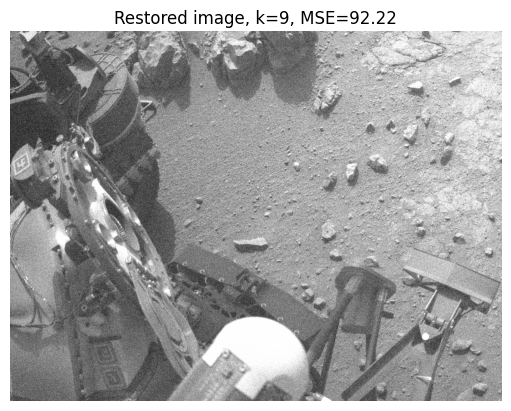

In [ ]:
ksize = 9
restoredImg = adaptiveRestorationVectorized(marsImage, ksize=ksize)
MSE = meanSquaredError(restoredImg, marsImage)
show(gaussNoisyImg, cmap="gray", title=f"Restored image, k={ksize}, MSE={MSE}")

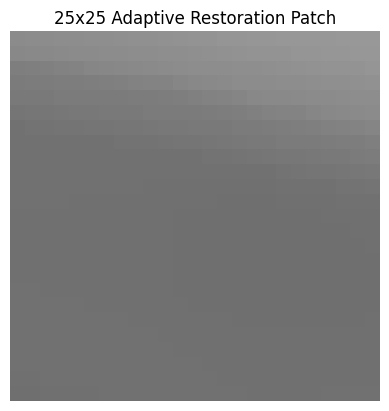

In [ ]:
restoredPatch = patch(restoredImg, height, width, ksize=25)
show(restoredPatch, cmap="gray", title="25x25 Adaptive Restoration Patch")

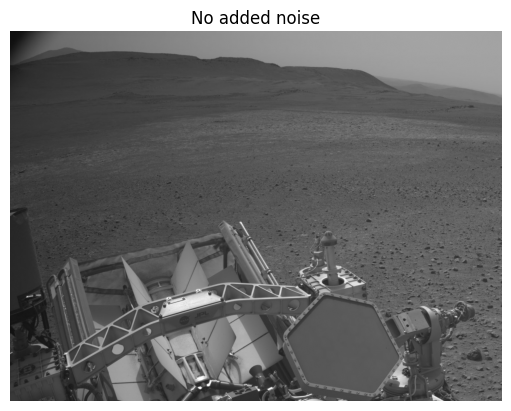

In [ ]:
show(marsImage, cmap="gray", title=f"No added noise")